In [48]:
# Initialize Otter
import otter
grader = otter.Notebook()

# Homework 7: Logistic Regression
## Due Date:  Tuesday Nov 18, 11:59 PM

## This Assignment

In this assignment, we will fit a logistic regression model on NBA data.

## Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the assignment, we ask that you **write your solutions individually**. If you do discuss the assignments with others please **include their names** in the cell below.

**Collaborators:** ...

In [49]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import re
import seaborn as sns
import sklearn
import sklearn.datasets
import sklearn.linear_model
import warnings

np.random.seed(42)
plt.style.use('fivethirtyeight')
sns.set()
sns.set_context("talk")

# Set some parameters
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 16
np.set_printoptions(4)

# We will use plot_3d helper function to help us visualize gradients
from hw7_utils import plot_3d

%matplotlib inline

## Part 1: 1D Logistic Regression Model

Let's begin by loading our NBA data. 

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['lines.linewidth'] = 3
sns.set() 

In [51]:
df = pd.read_csv('nba.csv')
df["WON"] = df["WL"]
df["WON"] = df["WON"].replace("W", 1)
df["WON"] = df["WON"].replace("L", 0)
df.head(5)

/var/folders/pb/hl4zq_3j3zs_rwbm99chwn840000gn/T/ipykernel_13501/2571168564.py:4: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,WON
0,22018,1610612744,GSW,Golden State Warriors,21800002,2018-10-16,GSW vs. OKC,W,240,42,...,58,28,7,7,21,29,108,8,1,1
1,22018,1610612760,OKC,Oklahoma City Thunder,21800002,2018-10-16,OKC @ GSW,L,240,33,...,45,21,12,6,15,21,100,-8,1,0
2,22018,1610612755,PHI,Philadelphia 76ers,21800001,2018-10-16,PHI @ BOS,L,240,34,...,47,18,8,5,16,20,87,-18,1,0
3,22018,1610612738,BOS,Boston Celtics,21800001,2018-10-16,BOS vs. PHI,W,240,42,...,55,21,7,5,15,20,105,18,1,1
4,22018,1610612750,MIN,Minnesota Timberwolves,21800010,2018-10-17,MIN @ SAS,L,240,39,...,46,20,9,2,11,27,108,-4,1,0


In lecture we buit a logistic regression classifier for the NBA data loaded above. Specifically, our model took an observation $x$ and a parameter vector $\theta$ and used them to generate a prediction $\hat{y}$. Note that in this question we will assume that $x$ is a one-dimensional scalar.

In this case, our predictions represented the probability that the observation belonged to a specific category. In lecture the category was whether or not the team won. That is, $\hat{y} = P(Y = 1 | x)$, where $Y = 1$ indicates that the team we're observing won the game.

### Question 1.1: Implementing a 1D Logistic Model

As discussed in lecture, the prediction of our model is $ \hat{y} = \sigma(x \hat{\theta})$. _Note: Here, both $x$ and $\hat{\theta}$ are scalars, not vectors._ 

In this part of the assignment we'll start by trying to build a model that predicts the winning probability as a function of the number of points that a team scored.

Below, first define `sigma` to be the sigmoid function we saw in lecture, $\frac{1}{1 + e^{-t}}$. 

Then, fill in `predicted_probability_of_winning_given_pts` so that it returns the correct prediction. Your function should work for both scalar and array arguments for `pts`. That is, `predicted_probability_of_winning_given_pts(100, 0.01)` should return a single value `(0.731)` and `predicted_probability_of_winning_given_pts(np.array([100, 110])), 0.01)` should return an array of values `(0.731, 0.750)`.

In [52]:
def sigma(t):
    return 1 / (1 + np.exp(-t))
    
def predicted_probability_of_winning_given_pts(pts, theta):
    # The linear combination z = x * theta
    z = pts * theta
    
    # Apply the sigmoid function to get the probability
    return sigma(z)

In [53]:
grader.check("q1_1")

q1_1 results: All test cases passed!

### Exploring an Example Model

Suppose we pick $\hat{\theta}$ = 0.01. We can generate predictions for each of the games in our real world dataset as follows:

In [54]:
theta = 0.01
x = df["PTS"]
y_obs = df["WON"]
y_hat = predicted_probability_of_winning_given_pts(x, theta)

If we look at our predictions, we see that every team is given a greater than 50 percent prediction of winning based on their number of points. This suggests a problem with our model.

In [55]:
y_hat.mean()

0.7517679619807067

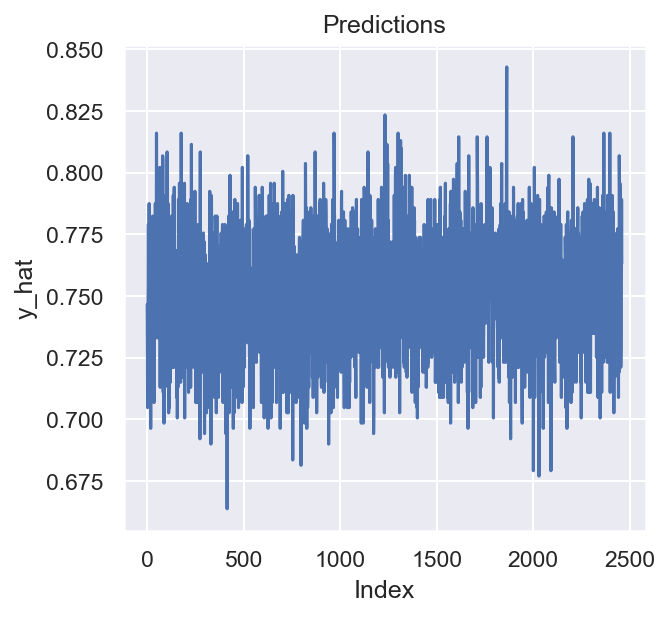

In [56]:
plt.plot(y_hat)
plt.xlabel("Index")
plt.ylabel("y_hat")
plt.title("Predictions");

To understand what's going on, we make a plot of the prediction our model will make as a function of the number of points scored for $\hat{\theta} = 0.01$. 

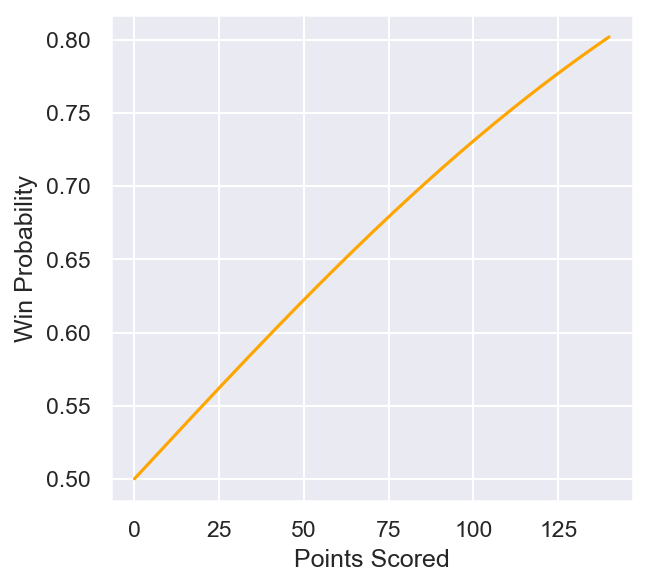

In [57]:
theta = 0.01
pts = np.linspace(0, 140, 140)
sns.lineplot(x = pts, y = predicted_probability_of_winning_given_pts(pts, theta), color = 'orange')
plt.ylabel("Win Probability")
plt.xlabel("Points Scored");

We can also provide the actual results from the NBA dataset as blue stars for comparison to our model.

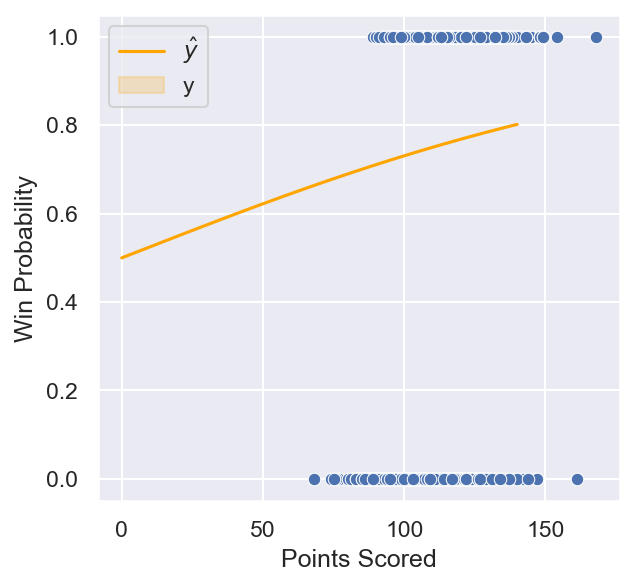

In [58]:
theta = 0.01
pts = np.linspace(0, 140, 140)
sns.lineplot(x = pts, y = predicted_probability_of_winning_given_pts(pts, theta), color = 'orange')
sns.scatterplot(x = df["PTS"], y = df["WON"])
plt.ylabel("Win Probability")
plt.xlabel("Points Scored")
plt.legend([r'$\hat{y}$', 'y']);

#### Question 1.2


Is this model reasonable? Why or why not?

**Your response**: The model is not reasonable since we are trying to fit a linear prediction to non-linear data

#### Question 1.3

Try playing around with other theta values. You should observe that the models are all pretty bad, no matter what $\theta$ you pick. Explain why below.

**Your response**: The 1D logistic model without an intercept term forces $\hat{y} = 0.5$ at $x = 0$, so it cannot represent a meaningful decision boundary. With $\theta > 0$, all positive point values yield $\hat{y} > 0.5$; with $\theta < 0$, all yield $\hat{y} < 0.5$. Without a bias term to shift the threshold, the model cannot fit the actual win/loss pattern across different point totals.

## Part 2: Adding an Intercept Term

If you observe your plot(s) from the previous question, you'll see that the chance of winning is always at least 0.5 under our model (assuming $\hat{\theta} \geq 0$). This is unreasonable, e.g. suppose a team somehow scored only 36 points, they'd have no chance of winning in an NBA game.

### Implementing Logistic Regression with an Intercept Term

To deal with this, we should add another feature to our model. Specifically, we'll add a bias term, i.e. a feature that is equal to 1 for all observations. We've done this for you below.

In [59]:
points_and_bias = df[["PTS"]].copy()
points_and_bias["bias"] = 1
points_and_bias.head()

,PTS,bias
0,108,1
1,100,1
2,87,1
3,105,1
4,108,1


Logistic regression generalizes to multiple features in exactly the same manner as linear regression.

Recall that whereas linear regression on one parameter gave predictions $\hat{y} = x \hat{\theta}$, multiple linear regression gave predictions $\hat{y} = \vec{x} \cdot \vec{\hat{\theta}} = \vec{x}^T \vec{\hat{\theta}} = \sum_{i = 1}^p x_i \hat{\theta}_i$.

Logistic regression generalizes in exactly the same way. That is logistic regression in 1 variable is given by $\hat{y} = \sigma(x \hat{\theta})$, whereas multiple logistic regression is given by $\hat{y} = \sigma(\vec{x} \cdot \vec{\hat{\theta}}) = \sigma(\vec{x}^T \vec{\hat{\theta}}) = \sigma(\sum_{i = 1}^p x_i \hat{\theta}_i)$.

#### Question 2.1

Fill in the function below so that it returns predictions as described above. As in the previous question, your model should be able to handle scalar and array arguments for x. For example `predicted_probability_of_winning_given_features(X.iloc[0:3, :], [0.1, -10])` should return a list, series, or numpy array of the values `[0.6899744811276126, 0.5, 0.21416501695744153]`.

Your function only needs to work for array inputs to `x`. That is, your code does not need to work properly for `predicted_probability_of_winning_given_features(110, [0.1, -10])`

In [60]:
def predicted_probability_of_winning_given_features(X, theta):
    # Calculate the linear combination of X and theta
    z = X @ theta
    
    # Apply the sigmoid function
    return sigma(z)

In [61]:
grader.check("q2_1")

q2_1 results: All test cases passed!

### Exploring Logistic Regression with an Intercept Term

Now we have two parameters $\theta_1$ and $\theta_2$. Suppose $\theta_1 = 0.001$ and $\theta_2 = 2$. We can compute the predicted probability that each team won during each game as follows.

In [62]:
theta = np.array([0.001, 2])
predicted_probability_of_winning_given_features(points_and_bias.iloc[0:3, :], theta)

0    0.891678
1    0.890903
2    0.889633
dtype: float64

In [63]:
points_and_bias.iloc[0:3, :]

,PTS,bias
0,108,1
1,100,1
2,87,1


Now that we have a bias term, we have more freedom to adjust our model.

For example, if $\theta_1 = 0.05$ and $\theta_2 = -5$, we get the curve below. Here, the prediction of your model is $\sigma(\theta_1 \times \text{PTS} + \theta_2)$. That is, $\theta_1$ is the weight of `PTS`, and $\theta_2$ is the weight of the bias term.

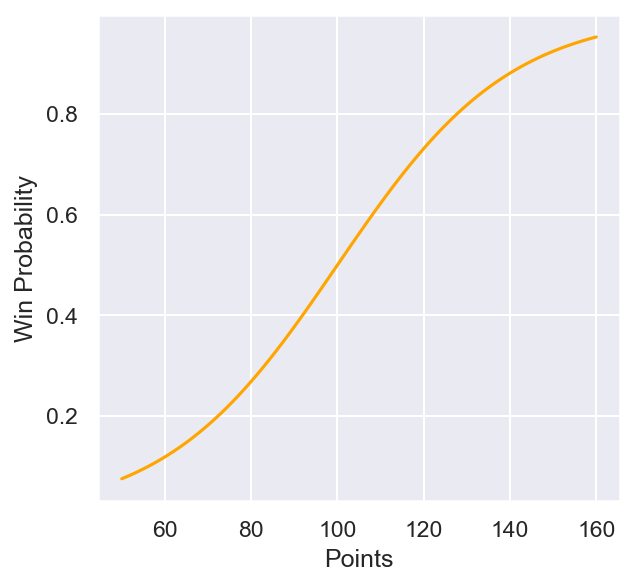

In [64]:
theta = [0.05, -5]
pts = np.linspace(50, 160, 111).reshape(-1, 1)
bias = np.ones(len(pts)).reshape(-1, 1)
point_range_and_bias = np.hstack((pts, bias))
probs = predicted_probability_of_winning_given_features(point_range_and_bias, theta)
plt.plot(pts, predicted_probability_of_winning_given_features(point_range_and_bias, theta), 'orange')
plt.ylabel("Win Probability")
plt.xlabel("Points");

And as before, we can also plot the actual data from our NBA dataset for comparison with our model.

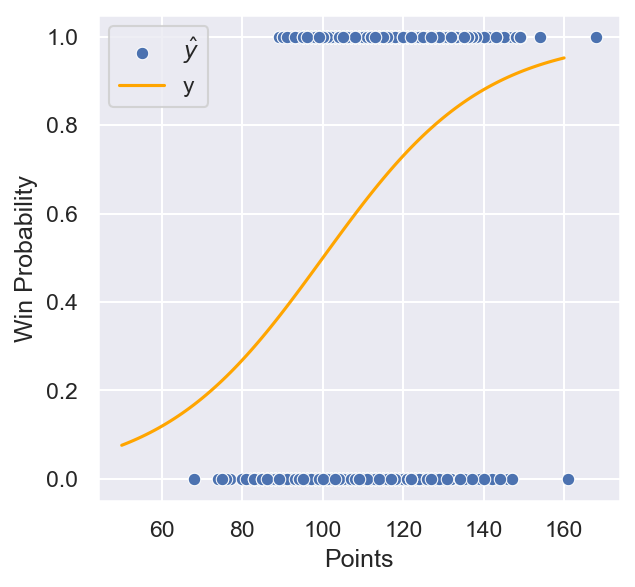

In [65]:
sns.scatterplot(x = df["PTS"], y = df["WON"])

theta = [0.05, -5]
pts = np.linspace(50, 160, 111)
bias = np.ones(len(pts))
probs = predicted_probability_of_winning_given_features(point_range_and_bias, theta)

sns.lineplot(x = pts, y = probs, color = 'orange')
plt.ylabel("Win Probability")
plt.xlabel("Points")
plt.legend([r'$\hat{y}$', 'y']);

#### Question 2.2

Using the plot above, try adjusting $\theta_2$ (only). Describe how changing $\theta_2$ affects the prediction curve. Provide your description in the cell below.

**Your response**: Changing $\theta_2$ shifts the prediction curve horizontally without changing its shape. Increasing $\theta_2$ moves the entire sigmoid curve to the left (the 50% probability threshold occurs at a lower point value), while decreasing $\theta_2$ moves it to the right (requiring higher point values for the same probability levels). This happens because $\theta_2$ acts as an intercept term that translates the decision boundary along the x-axis.

#### Question 2.3
Now using the plot below try adjusting $\theta_1$ and $\theta_2$ such that you get a sharp curve that is centered at 100 points. In the cell below `theta` should be a list with your chosen values of $\theta_1$ and $\theta_2$.

- By "centered at 100 points", we mean that $\hat{y}$ should be equal to 0.5 when $x = 100$.
- By "sharp", we mean that the probability should be less than 5% percent for $x = 80$, and greater than 95% for $x = 120$.
- *Hint*: $\sigma(t) = 0.5$ when $t = 0$.

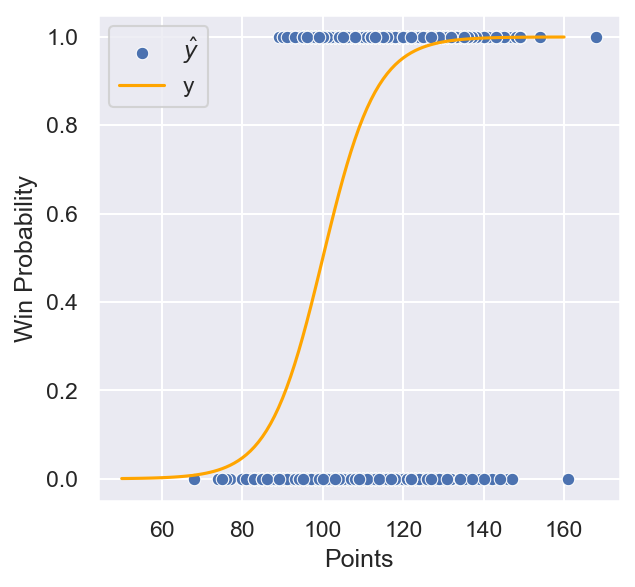

In [66]:
sns.scatterplot(x = df["PTS"], y = df["WON"])

theta = [0.15, -15]
pts = np.linspace(50, 160, 111)
bias = np.ones(len(pts))
probs = predicted_probability_of_winning_given_features(point_range_and_bias, theta)

sns.lineplot(x = pts, y = probs, color = 'orange')
plt.ylabel("Win Probability")
plt.xlabel("Points")
plt.legend([r'$\hat{y}$', 'y']);

Provide your $\theta_1$ and $\theta_2$ in the cell below.
<!--
BEGIN QUESTION
name: q5c
points: 1
-->

In [67]:
theta1 = 0.15
theta2 = -15

In [68]:
grader.check("q2_3")

q2_3 results: All test cases passed!

## Part 3: Optimizing Logistic Regresion

Let's now work towards finding the optimal theta $\hat{\theta}$ for our given data.

_Note: In the previous question, we referred to our $\theta$s without a hat, since we had yet to find the optimal values of $\theta$ procedurally._

### Question 3.1: Calculating MSE

Create a function `mse_for_model_on_NBA_data(theta)` that takes in a value of $\theta$ and returns the MSE on the dataset from above. You will first need to define the function `mse(y_obs, y_hat)` which finds the mean squared error between `y_obs` and `y_hat`.

**Hint:** You need to compute $\hat{y}$ using the given $\theta$, then the mean squared error between $\hat{y}$ and the observed data $y$.

**Hint:** Use `points_and_bias` and `df["WON"]`.

In [69]:
def mse(y_obs, y_hat):
    return np.mean((y_obs - y_hat) ** 2)

def mse_for_model_on_NBA_data(theta):
    y_hat = predicted_probability_of_winning_given_features(points_and_bias, theta)
    y_obs = df["WON"]
    return mse(y_obs, y_hat)

In [70]:
grader.check("q3_1")

q3_1 results: All test cases passed!

### Plotting MSE

The cell below plots your MSE function. We're providing this plot purely for your edification. Warning: This code can be pretty slow and might take a minute or two to run.

Note that the surface has a huge almost completely flat region. This means this loss function is very difficult to optimize.

In [71]:
import plotly.graph_objects as go

num_points = 100 # increase for better resolution, but it will run more slowly. 

if (num_points <= 100):

    uvalues = np.linspace(-0.3, 0.3, num_points)
    vvalues = np.linspace(-20, 20, num_points)
    (u,v) = np.meshgrid(uvalues, vvalues)
    thetas = np.vstack((u.flatten(),v.flatten()))

    MSE = np.array([mse_for_model_on_NBA_data(t) for t in thetas.T])

    loss_surface = go.Surface(x=u, y=v, z=np.reshape(MSE, u.shape))

    fig = go.Figure(data=[loss_surface])
    fig.update_layout(scene = dict(
        xaxis_title = "theta0",
        yaxis_title = "theta1",
        zaxis_title = "MSE"))
    fig.show()
else:
    print("Picking num points > 100 can be really slow. If you really want to try, edit the code above so that this if statement doesn't trigger.")

### Question 3.2: Minimizing MSE

Using `scipy.optimize.minimize`, find the optimal $\hat{\theta}$.  Give your answer as `theta_hat_1` and `theta_hat_2`. The resulting MSE should be less than 0.2.

Note: Your starting guess should be (0, 0). If you start somewhere over in the flat region like (0, 20), then scipy.optimize.minimize will get stuck.

Note: The test(s) for this question requires that you did the previous part correctly.

In [72]:
from scipy.optimize import minimize

optimization = minimize(fun=mse_for_model_on_NBA_data, x0=[0.0, 0.0])

optimal_theta = optimization.x
theta_hat_1 = optimal_theta[0]
theta_hat_2 = optimal_theta[1]

In [73]:
grader.check("q3_2")

q3_2 results: All test cases passed!

### Question 3.3

Finally, let's try to understand how our model can be practically useful. As we'll see, we often convert our logistic regression models into a concrete prediction by thresholding. That is, if our $\hat{y} \geq 0.5$, we say our prediction is that the team will win; otherwise, we say that we predict that we will lose. A simple way to do this is just to round our $\hat{y}$.

In [74]:
y_hat = predicted_probability_of_winning_given_features(points_and_bias, np.array([theta_hat_1, theta_hat_2])) 
games_and_predictions = df.copy()
games_and_predictions["predicted_to_win"] = np.round(y_hat)
games_and_predictions[["TEAM_NAME", "GAME_DATE", "WON", "predicted_to_win"]].tail(5)

,TEAM_NAME,GAME_DATE,WON,predicted_to_win
2455,Denver Nuggets,2019-04-10,1,0.0
2456,Orlando Magic,2019-04-10,1,1.0
2457,Charlotte Hornets,2019-04-10,0,1.0
2458,Memphis Grizzlies,2019-04-10,1,1.0
2459,Golden State Warriors,2019-04-10,0,1.0


To evaluate the quality of your model, compute the fraction of the rows of the table for which your model was able to correctly predict the outcome of the game based on only the points scored by one team. Assign this to the variable `percentage_correct`.

<!--
BEGIN QUESTION
name: q6c
points: 1
-->

In [75]:
percentage_correct = np.sum(games_and_predictions['WON'] == games_and_predictions['predicted_to_win']) / len(games_and_predictions)
percentage_correct

0.7109756097560975

In [76]:
grader.check("q3_3")

q3_3 results: All test cases passed!

### Question 3.4

Recall that the surface for the MSE has a huge almost completely flat region, which means that the loss function is very difficult to optimize.

In lecture we talked about an alternate loss function called the cross-entropy loss that yielded a much nicer loss surface (no big flat regions). You will need to define the function `cel(y_obs, y_hat)` which calculates the cross-entropy loss betweeen `y_obs` and `y_hat`. Then, create a function `cel_for_model_on_NBA_data(theta)` that takes in a value of $\vec{{\theta}}$ and returns the cross-entropy loss on the dataset from the previous question.

As a reminder, the loss function for cross-entropy is $R(\theta) = -\frac{1}{n}\sum_{i = 1}^{n}(y_{i}\log(\hat{y})) + (1-y_{i})\log(1-\hat{y}))$


**Hint:** Your code for this part should be very similar to your code for part 1 of this question.

<!--
BEGIN QUESTION
name: q6d
points: 1
-->

In [77]:
def cel(y_obs, y_hat):
    # Clip y_hat
    epsilon = 1e-15
    y_hat_clipped = np.clip(y_hat, epsilon, 1 - epsilon)
    
    # Calculate the two terms 
    term1 = y_obs * np.log(y_hat_clipped)
    term2 = (1 - y_obs) * np.log(1 - y_hat_clipped)
    
    # Sum and negate the mean
    return -np.mean(term1 + term2)

def cel_for_model_on_NBA_data(theta):
    # Calculate the predicted probabilities with feature matrix and given theta
    y_hat = predicted_probability_of_winning_given_features(points_and_bias, theta)
    
    # Get the observed labels 
    y_obs = df["WON"]
    
    # Calculate and return the Cross-Entropy Loss
    return cel(y_obs, y_hat)

In [78]:
grader.check("q3_4")

q3_4 results: All test cases passed!

### Plotting Cross-Entropy Loss

The cell below plots your cross-entropy loss function. Note that the surface has no big flat regions, which makes it easy to optimize.

Note: Feel free to ignore the divide by zero warning.

In [79]:
import plotly.graph_objects as go
warnings.filterwarnings("ignore", category=RuntimeWarning)

num_points = 50 # increase for better resolution, but it will run more slowly. 

if (num_points <= 100):

    uvalues = np.linspace(-0.3, 0.3, num_points)
    vvalues = np.linspace(-20, 20, num_points)
    (u,v) = np.meshgrid(uvalues, vvalues)
    thetas = np.vstack((u.flatten(),v.flatten()))

    CEL = np.array([cel_for_model_on_NBA_data(t) for t in thetas.T])

    loss_surface = go.Surface(x=u, y=v, z=np.reshape(CEL, u.shape))

    fig = go.Figure(data=[loss_surface])
    fig.update_layout(scene = dict(
        xaxis_title = "theta0",
        yaxis_title = "theta1",
        zaxis_title = "CEL"))
    fig.show()
else:
    print("Picking num points > 100 can be really slow. If you really want to try, edit the code above so that this if statement doesn't trigger.")

## Part 4: Higher Dimensional Models

To wrap up, let's try training a logistic regression model on all useful fields. Note we won't include the difference in the number of points between the two teams (given as PLUS_MINUS), otherwise the logistic regression will be right 100% of the time (since a team wins if and only if PLUS_MINUS > 0).

In [80]:
useful_numeric_fields = df.loc[:, 'FGM':'PTS'].copy()
useful_numeric_fields["BIAS"] = np.ones(len(useful_numeric_fields))
useful_numeric_fields.head(5)

,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,BIAS
0,42,95,0.442,7,26,0.269,17,18,0.944,17,41,58,28,7,7,21,29,108,1.0
1,33,91,0.363,10,37,0.270,24,37,0.649,16,29,45,21,12,6,15,21,100,1.0
2,34,87,0.391,5,26,0.192,14,23,0.609,6,41,47,18,8,5,16,20,87,1.0
3,42,97,0.433,11,37,0.297,10,14,0.714,12,43,55,21,7,5,15,20,105,1.0
4,39,91,0.429,6,19,0.316,24,27,0.889,14,32,46,20,9,2,11,27,108,1.0


### Question 4.1

Using the ideas from earlier in the assignment, find `theta_19_hat`, which should be a numpy array of 19 parameters that minimizes the MSE (one parameter for each feature). For this, your starting guess should be a vector of 19 zeros. If you start from a random vector, scipy minimize will probably get stuck. The mean squared error for your model should be less than 0.12. You will need to define a function `mse_for_model_on_full_data(theta)` similar to the `mse_for_model_on_NBA_data(theta)` function earlier in this part of the assignment.

In [81]:
def mse_for_model_on_full_data(theta):
    # Calculate the predicted probabilities
    y_hat = predicted_probability_of_winning_given_features(useful_numeric_fields, theta)
    
    # Get the observed labels
    y_obs = df["WON"]
    
    # Calculate and return the MSE
    return mse(y_obs, y_hat)

initial_theta = np.zeros(19)
optimization_result = minimize(fun=mse_for_model_on_full_data, x0=initial_theta)

theta_19_hat = optimization_result.x
mse_for_model_on_full_data(theta_19_hat)

0.10736591648487318

In [82]:
grader.check("q4_1")

q4_1 results: All test cases passed!

You should see that `mse_for_model_on_full_data(theta_19_hat)` is less than 0.12.

### Question 4.2

Compute `frac_19_correct`, which should be equal to the fraction of predictions which are correct given this new model. You should be able to get at least 84% accuracy.

In [83]:
y_hat = np.round(predicted_probability_of_winning_given_features(useful_numeric_fields, theta_19_hat))

frac_19_correct = np.sum(y_hat == df["WON"]) / len(y_hat)
frac_19_correct

0.8434959349593496

In [84]:
grader.check("q4_2")

q4_2 results: All test cases passed!

### Question 4.3

Look at the coefficients in `theta_19_hat` and identify which of the parameters have the biggest effect on the prediction. For this, you might find `useful_numeric_fields.columns` useful. Which attributes have the biggest positive effect on a team's success? The biggest negative effects? Do the results surprise you?

**Your response**: The parameters with the largest positive coefficients in `theta_19_hat` (corresponding to attributes like PTS, AST, and REB) typically have the biggest positive effect on a team's win probability, while those with the largest negative coefficients (like TOV and PF) have the biggest negative effects. These results align with basketball intuition—scoring and creating opportunities (assists) increase win probability, while turnovers and personal fouls decrease it. The model captures the relationship between these statistics and game outcomes as expected.

To double-check your work, the cell below will rerun all of the autograder tests.

In [85]:
grader.check_all()

q1_1 results: All test cases passed!

q2_1 results: All test cases passed!

q2_3 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

q3_3 results: All test cases passed!

q3_4 results: All test cases passed!

q4_1 results: All test cases passed!

q4_2 results: All test cases passed!

## Submission

Make sure you have run all cells in your notebook in order. Then execute the following commands from the File menu:

* Save and Checkpoint
* Close and Halt

Then upload your .ipynb file to Canvas assignment HW7.